# Quickstart: charts from a table

Inklet draws publication-sized charts from a table in one call, measures the
text so labels do not collide, and saves SVG, PDF or PNG. This notebook runs
top to bottom; every chart appears where its cell runs.

Install it from [PyPI](https://pypi.org/project/inklet/):

```sh
pip install inklet
```


In [1]:
import numpy as np
import pandas as pd
import inklet as i

rng = np.random.default_rng(2024)   # a fixed seed: the same simulated data on every run

# A simulated time course: 2 cell lines x 3 treatments x 3 replicates, sampled hourly.
df = pd.MultiIndex.from_product(
    [['HeLa', 'U2OS'], ['control', 'drug A', 'drug B'], [1, 2, 3], np.arange(9)],
    names=['cell_line', 'treatment', 'replicate', 'hour']).to_frame(index=False)
gain = df['treatment'].map({'control': 0.0, 'drug A': 0.4, 'drug B': 0.8})
base = df['cell_line'].map({'HeLa': 1.0, 'U2OS': 1.4})
df['signal'] = (base + gain * np.log1p(df['hour']) + rng.normal(0, 0.12, len(df))).round(2)

# Hourly means and standard errors, one row per group and hour.
summary = (df.groupby(['cell_line', 'treatment', 'hour'])['signal']
             .agg(mean='mean', sem='sem').reset_index())
hela = summary[summary['cell_line'] == 'HeLa']
endpoint = df[df['hour'] == 8]   # the last hour, one row per replicate

df.head(8)


,cell_line,treatment,replicate,hour,signal
0,HeLa,control,1,0,1.12
1,HeLa,control,1,1,1.20
2,HeLa,control,1,2,1.14
3,HeLa,control,1,3,0.88
4,HeLa,control,1,4,0.83
5,HeLa,control,1,5,1.01
6,HeLa,control,1,6,1.10
7,HeLa,control,1,7,1.06


## Lines with groups

`color=` draws one line per group, and `error_y=` adds a band. Axis titles come
from the column names unless you give them.


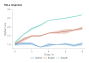

In [2]:
i.line(hela, x='hour', y='mean', color='treatment', error_y='sem',
       xlabel='Time / h', ylabel='Signal / a.u.', title='HeLa response')


## Scatter with text labels

`text=` labels each point, placed clear of the marks and of each other.
These compounds are simulated.


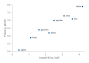

In [3]:
compounds = pd.DataFrame({
    'compound': ['alpha', 'beta', 'gamma', 'delta', 'epsilon', 'zeta', 'eta', 'theta'],
    'logP': [0.4, 1.1, 1.6, 2.2, 2.5, 3.1, 3.6, 4.2],
    'pIC50': [5.1, 5.9, 6.4, 6.2, 7.0, 7.3, 7.1, 7.9],
})
i.scatter(compounds, x='logP', y='pIC50', text='compound',
          xlabel='Lipophilicity, logP', ylabel='Potency, pIC50')


## Bars with means, error bars and points

`agg='mean'` averages the rows in each category instead of summing them.
`error_y='sem'` draws the standard error, and `points=True` shows every replicate.


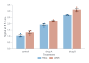

In [4]:
i.bar(endpoint, x='treatment', y='signal', color='cell_line', agg='mean',
      error_y='sem', points=True, xlabel='Treatment', ylabel='Signal at 8 h / a.u.')


## Box plots with points

`points=True` overlays the individual samples on each box.


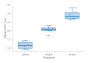

In [5]:
i.boxplot(endpoint, x='treatment', y='signal', points=True,
          xlabel='Treatment', ylabel='Signal at 8 h / a.u.')


## Small multiples

`facet_col=` makes one panel per value. The panels share their axes, and each
treatment keeps its colour in every panel.


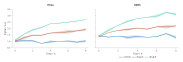

In [6]:
i.line(summary, x='hour', y='mean', color='treatment', error_y='sem',
       facet_col='cell_line', xlabel='Time / h', ylabel='Signal / a.u.')


## Direct labels

`legend='direct'` names each line at its end, so no key is needed.


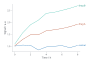

In [7]:
i.line(hela, x='hour', y='mean', color='treatment', legend='direct',
       xlabel='Time / h', ylabel='Signal / a.u.')


## Multi-panel figures

`|` places charts side by side and `/` stacks them. Each panel gets a letter.


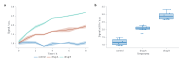

In [8]:
figure = (i.line(hela, x='hour', y='mean', color='treatment', error_y='sem',
                  xlabel='Time / h', ylabel='Signal / a.u.')
          | i.boxplot(endpoint, x='treatment', y='signal', points=True,
                      xlabel='Treatment', ylabel='Signal at 8 h / a.u.'))
figure


## Save and check

`save()` writes each file by its extension and returns the compiled figure.
`figure.report()` lists overlapping or clipped text, small type, and data
outside the axes, each with a suggested fix. An empty report means no problems.


In [9]:
figure.save('quickstart.svg', 'quickstart.pdf')
print(figure.report())


inklet lint: clean, 0 diagnostics


## Existing matplotlib figures

`i.from_matplotlib(fig)` redraws the data of a matplotlib figure as Inklet
charts, so the plotting code can stay as it is. Here the figure is closed before
the cell ends, so only the Inklet version is displayed.


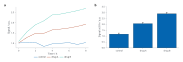

In [10]:
import matplotlib.pyplot as plt

fig, (left, right) = plt.subplots(1, 2, figsize=(7.2, 2.6))
for treatment, group in hela.groupby('treatment'):
    left.plot(group['hour'], group['mean'], label=treatment)
means = endpoint.groupby('treatment')['signal'].agg(['mean', 'sem'])
right.bar(means.index, means['mean'], yerr=means['sem'], capsize=3)
left.set_xlabel('Time / h')
left.set_ylabel('Signal / a.u.')
right.set_ylabel('Signal at 8 h / a.u.')
left.legend()

converted = i.from_matplotlib(fig)
plt.close(fig)
converted


## Where next

- [Charts in one call](https://inklet.readthedocs.io/en/latest/quick-charts/):
  every chart type and option.
- [Using Inklet with coding agents](https://inklet.readthedocs.io/en/latest/coding-agents/):
  the guide an agent reads, and how to check its figures.
- [Published figures](https://inklet.readthedocs.io/en/latest/published-figures/):
  eight figures recreated from their data.
